# DSCI235 Final Project
**Stella Kaulbach** and **Tucker Sussenbach**

Github: https://github.com/sussenbachtucker/DSCI235-Term-Project



### Introduction

For this project, we are going to be analyzing a portion of the 2022 Environmental Performance Index (EPI) report which ranks 180 countries on various performance indicators related to environmental health, ecosystem vitality, and climate change. We will focus on the environmental health data, which includes 13 performance indicators specifically focused on quantifying the air quality, sanitation and drinking water, heavy metal (lead) exposure, and waste management of each country over time For each indicator. Each indicator is a score from 0-100 on how that country performed on that particular metric. The scores were generated by the University of Columbia based on applying specific transformations to each metric; for more information, see the Technical Appendix in the repository. 

This data is publicly available in the [EARTHDATA](https://www.earthdata.nasa.gov/data/catalog/sedac-ciesin-sedac-epi-2022-2022.00) website, which is the portal for the Earth Science Data Systems (ESDS) Program, providing open access to NASA’s archive of Earth science data. Throughout this report, we will make use of the information provided in the Technical Appendix, included when you download the data. We have included this pdf in the files on the github repository under the name "2022-epi-technical-appendix.pdf". 

The structure of the data is as follows: there are 13 CSV files, each one focusing on a particular performance indicator for environmental health. A CSV file for a given performance indicator contains a country’s name, ISO code (both the 3 digit abbreviation and the number), and the EPI score for that country for the given performance indicator for years between 1995 and 2022 (inclusive). The way that the data is compiled allows for comparisons of a country over time and countries with each other. 

The main goal of our analysis will be to combine these 13 performance indicators into a single rating for each country in a given year that will quantify the overall environmental health of that country at that time. We would also like to quantify the overall change in environmental health for each country between 1995 and 2022. Then, we will analyze the resulting ratings and rates of change to see if there are any noticeable patterns, countries of significance, or unusual outliers. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Organization and Cleaning

For our main data structure, we chose to use a MultiIndex dataframe to hold all our datapoints. The MultiIndex allows us to access our data in several different manners, making it very easy to do analysis by country, year, or indicator (or a combination of those). Thus, we have `all_data`, which holds every datapoint and can be indexed in several different ways. 

In [4]:
indicators = ["PMD", "HAD", "OZD", "NOE", "SOE", "COE", "VOE", "USD", "UWD", "PBD", "MSW", "REC", "OCP"]
datasets = []

for x in indicators:
    x_init = pd.read_csv("HLT\\"+x+"_ind_na.csv")
    
    x_long = x_init.melt(id_vars=["code", "iso", "country"], var_name="indicator_year", value_name="value") 
    
    x_long["indicator"] = x
    x_long["year"] = x_long["indicator_year"].str[-4:].astype(int)
    
    x_long = x_long.drop(columns=["indicator_year"])
    
    datasets.append(x_long)
    
all_data = pd.concat(datasets, ignore_index=True)

all_data = all_data.set_index(["code", "iso", "year", "indicator"]).sort_index()

all_data

country      value
code iso year indicator                        
4    AFG 1995 COE        Afghanistan  46.499051
              HAD        Afghanistan   0.000000
              MSW        Afghanistan   1.060000
              NOE        Afghanistan  45.528483
              OCP        Afghanistan        NaN
...                              ...        ...
894  ZMB 2022 REC             Zambia  12.630000
              SOE             Zambia  43.907576
              USD             Zambia  13.924561
              UWD             Zambia  13.248474
              VOE             Zambia  12.812337

[80080 rows x 2 columns]

We also felt that it would be necessary to search for the numeric code associated with each country, so we created `iso_dict` is a dictionary that holds the name of each country as the key and then its corresponding numeric code as a value. This is used primarily in the final section, where we look at the performance indicators of specific countries over time.

In [5]:
iso_dict = all_data["country"].droplevel(("year", "indicator"))
iso_dict = iso_dict.reorder_levels(["code", "iso"]).index
iso_dict = dict(zip(all_data["country"], iso_dict.get_level_values("code")))
iso_dict

{'Afghanistan': 4,
 'Albania': 8,
 'Algeria': 12,
 'Andorra': 20,
 'Angola': 24,
 'Antigua and Barbuda': 28,
 'Azerbaijan': 31,
 'Argentina': 32,
 'Australia': 36,
 'Austria': 40,
 'Bahamas': 44,
 'Bahrain': 48,
 'Bangladesh': 50,
 'Armenia': 51,
 'Barbados': 52,
 'Belgium': 56,
 'Bermuda': 60,
 'Bhutan': 64,
 'Bolivia': 68,
 'Bosnia and Herzegovina': 70,
 'Botswana': 72,
 'Brazil': 76,
 'Belize': 84,
 'Solomon Islands': 90,
 'British Virgin Islands': 92,
 'Brunei Darussalam': 96,
 'Bulgaria': 100,
 'Myanmar': 104,
 'Burundi': 108,
 'Belarus': 112,
 'Cambodia': 116,
 'Cameroon': 120,
 'Canada': 124,
 'Cabo Verde': 132,
 'Cayman Islands': 136,
 'Central African Republic': 140,
 'Sri Lanka': 144,
 'Chad': 148,
 'Chile': 152,
 'China': 156,
 'Taiwan': 158,
 'Colombia': 170,
 'Comoros': 174,
 'Republic of Congo': 178,
 'Dem. Rep. Congo': 180,
 'Cook Islands': 184,
 'Costa Rica': 188,
 'Croatia': 191,
 'Cuba': 192,
 'Cyprus': 196,
 'Czech Republic': 203,
 'Benin': 204,
 'Denmark': 208,
 'Do

### Developing an Overall Environmental Health Rating

In the Technical Appendix, each indicator is given a weight which represents the significance of that particular metric to the category that it is in. For example, the PMD indicator (PM<sub>2.5</sub> Exposure) is given a 47% weight, which means that it is 47% of the AIR (Air Quality) category. Since we eventually want to have a single score that measures overall Environmental Health (HTL) of a given country, we need to get the weights of each performance indicator in terms of the overall category HLT. 

The below image comes directly from page 3 of the Technical Appendix, and serves as a reference of where the numbers in `weight_indiv` and `weight_group` come from. 

![Subsection of Table from page 3 of Technical Appendix](HLT_Weights.png)

Thus, we multiplied each individual weight (value in `weight_indiv`) by the weight of that category (value in `weight_group`), and then had to do a bit of normalizing to make sure that all the final weights summed to 1. The result is `weight`, which holds a value representing the significance of each performance indicator to the overall category of Environmental Health. 

In [7]:
weight_indiv = pd.Series({"PMD": 0.47, "HAD": 0.38, "OZD": 0.05, "NOE": 0.05, "SOE": 0.02, "COE": 0.02, "VOE": 0.02, "USD": 0.40, "UWD":0.60, "PBD": 1.00, "MSW": 0.50, "REC": 0.25, "OCP": 0.25})
weight_group = pd.Series({"PMD": 0.55, "HAD": 0.55, "OZD": 0.55, "NOE": 0.55, "SOE": 0.55, "COE": 0.55, "VOE": 0.55, "USD": 0.25, "UWD":0.25, "PBD": 0.10, "MSW": 0.10, "REC": 0.10, "OCP": 0.10})

weight = weight_indiv * weight_group
weight /= weight.sum()
weight

PMD    0.257086
HAD    0.207857
OZD    0.027350
NOE    0.027350
SOE    0.010940
COE    0.010940
VOE    0.010940
USD    0.099453
UWD    0.149180
PBD    0.099453
MSW    0.049727
REC    0.024863
OCP    0.024863
dtype: float64

Now that we have the weights associated with each indicator, we need to add the weights onto the dataframe for future weighted average computations. So, we made new 2 columns in the dataframe. `weight` is the actual weight associated with each indicator for the overall environmental health rating. Then, we created the `weighted_value` column to represent the value of each indicator with respect to the weight of that indicator.

*We created a new dataframe so the original dataframe is unaffected*

In [8]:
weighted_data = all_data.copy()
weighted_data['weight'] = weighted_data.index.get_level_values('indicator').map(weight)
weighted_data['weighted_value'] = weighted_data['value'] * weighted_data['weight']
weighted_data.head()

country      value    weight  weighted_value
code iso year indicator                                                  
4    AFG 1995 COE        Afghanistan  46.499051  0.010940        0.508692
              HAD        Afghanistan   0.000000  0.207857        0.000000
              MSW        Afghanistan   1.060000  0.049727        0.052710
              NOE        Afghanistan  45.528483  0.027350        1.245185
              OCP        Afghanistan        NaN  0.024863             NaN

In order to get a single rating for each country for a given year, we needed to take the weighted average of all the performance indicators using the weights from above. This will give us a single value from 0 - 100 that quantifies the overall environmental health for a country in a given year.

However, not all country has ratings for all 13 indicators, so we need to make sure that our average calculations are accounting for the missing data. To do this, we also keep track of the sum of the weights, and then normalize the averages using their weight sums.

In [9]:
temp_df = weighted_data.dropna(subset=['weighted_value', 'weight']).groupby(level=['code','year']).agg(weighted_sum=('weighted_value', 'sum'), weight_sum=('weight', 'sum'))
temp_df['weighted_avg'] = temp_df['weighted_sum'] / temp_df['weight_sum']
temp_df

weighted_sum  weight_sum  weighted_avg
code year                                        
4    1995     15.250911    0.975137     15.639766
     1996     15.332889    0.975137     15.723835
     1997     15.055237    0.975137     15.439104
     1998     14.846390    0.975137     15.224931
     1999     14.676584    0.975137     15.050795
...                 ...         ...           ...
894  2018     20.816443    0.975137     21.347204
     2019     21.165970    0.975137     21.705643
     2020     21.171291    0.975137     21.711100
     2021     21.171291    0.975137     21.711100
     2022     21.171291    0.975137     21.711100

[6160 rows x 3 columns]

Now that we have our weighted averages, we would like to combine this with parts of original dataframe to have `code` and `country` values also accessible in the same data structure as the weighted averages. Initially, the rows were duplicated several times over because of the structure of the `all_data` dataframe, so we had to do some mindful dropping of duplicate rows to ensure our data was concise.

In [10]:
# doa a choin
weighted_avgs = all_data.droplevel('indicator')
weighted_avgs.drop('value', axis=1, inplace=True)
weighted_avgs = weighted_avgs.join(temp_df, how = "outer")
weighted_avgs.drop(columns=['weighted_sum', 'weight_sum'], inplace=True)
weighted_avgs["year"] = weighted_avgs.index.get_level_values("year")
weighted_avgs.drop_duplicates(inplace=True)
weighted_avgs.drop("year", axis = 1, inplace=True)
weighted_avgs

country  weighted_avg
code iso year                           
4    AFG 1995  Afghanistan     15.639766
         1996  Afghanistan     15.723835
         1997  Afghanistan     15.439104
         1998  Afghanistan     15.224931
         1999  Afghanistan     15.050795
...                    ...           ...
894  ZMB 2018       Zambia     21.347204
         2019       Zambia     21.705643
         2020       Zambia     21.711100
         2021       Zambia     21.711100
         2022       Zambia     21.711100

[6160 rows x 2 columns]

### Analysis of the Environmental Health Rating

Now that we have a single rating for overall environmental health for each country in a given year, we will do some analysis on how the countries compare to one another. We will look at which countries had the best and worst ratings overall (and for our most recent data). Then, we will group countries by their ratings for 1995 and 2022 and see what the most common range of ratings.

**Which countries had the best and worst ratings for all years available?**

In [11]:
sorted_avgs = weighted_avgs.sort_values(by = "weighted_avg")
sorted_avgs.head(10), sorted_avgs.tail(10)

(               country  weighted_avg
 code iso year                       
 356  IND 1998    India      7.748112
          1997    India      7.792811
          1999    India      7.989086
          2000    India      8.083913
          2001    India      8.188146
          1995    India      8.191865
          1996    India      8.216341
          2002    India      8.388171
          2003    India      8.782292
 426  LSO 2013  Lesotho      8.983694,
                country  weighted_avg
 code iso year                       
 246  FIN 2017  Finland     93.139378
 352  ISL 2014  Iceland     93.305664
          2015  Iceland     93.696851
          2016  Iceland     93.708201
          2017  Iceland     94.263508
          2018  Iceland     94.337965
          2019  Iceland     94.432641
          2022  Iceland     94.489211
          2020  Iceland     94.489211
          2021  Iceland     94.489211)

As we can see in the dataframe above, *India* had the 9 of the worst overall ratings (from 1995 to 2003) followed by Lesotho in 2013. Thus, India in the late 1990s and early 2000s was performing worst in terms of overall environmental health. It is important to note that India's rating was fluctuating during that period, as opposed to slowly declining or improving. Because of how minor the changes are in India's scores year by year, I would expect to see that India has a roughly constant rate of change (likely positive but close to 0).


For the overall best ratings, we can see that *Iceland* had the 9 best ratings (from 2014 to 2021), with a slight increase or no change over time. So, Iceland had very good ratings and still continued to minorly improve. I would also expect to see that Iceland actually also has a relatively constant rate of change.

**Which countries had the best and worst environmental health ratings for 2022?**

In [12]:
sorted_avgs_2022 = sorted_avgs.xs(2022, level = 2)
sorted_avgs_2022.head(10), sorted_avgs_2022.tail(10)

(                           country  weighted_avg
 code iso                                        
 426  LSO                   Lesotho     11.162792
 586  PAK                  Pakistan     11.317140
 356  IND                     India     12.468973
 140  CAF  Central African Republic     13.516145
 120  CMR                  Cameroon     14.473288
 887  YEM                     Yemen     15.156355
 566  NGA                   Nigeria     15.302739
 4    AFG               Afghanistan     16.452548
 624  GNB             Guinea-Bissau     16.779190
 524  NPL                     Nepal     16.904048,
               country  weighted_avg
 code iso                           
 208  DNK      Denmark     85.187352
 124  CAN       Canada     85.577380
 36   AUS    Australia     86.044200
 442  LUX   Luxembourg     86.502758
 372  IRL      Ireland     88.109023
 756  CHE  Switzerland     88.345493
 578  NOR       Norway     91.818733
 752  SWE       Sweden     92.847432
 246  FIN      Finland     93

For the year 2022 (our most recent data available), we can see that the worst rated country overall is *Lesotho*. In general, the 10 countries with the worst ratings are all in Africa (5), South Asia (3), and the Greater Middle East (2). This is not surprising, as it speaks to the idea that developing countries do not have the economic ability to prioritize environmental well-being. 

In contrast, the 10 countries with the best environmental health ratings are located in Europe (mostly Northern and Western Europe), with the exception of Canada and Australia. The country with the best overall rating is *Iceland*, which is not surprising as it was listed in the overall best ratings for all time in 2022. Overall, we would expect to see these developed nations having higher environmental health scores. However, it is worth noting that America, China, and Russia, which are all regularly considered global 'superpowers', are not in the top 10 countries for environmental health. 

Beyond looking at the best and worst countries for environmental health in 2022, we wanted to group countries by their environmental health scores in 2022 and place this data in a histogram to give us more information on the distribution of environmental health ratings across the all countries.

Text(0, 0.5, 'Number of Countries')

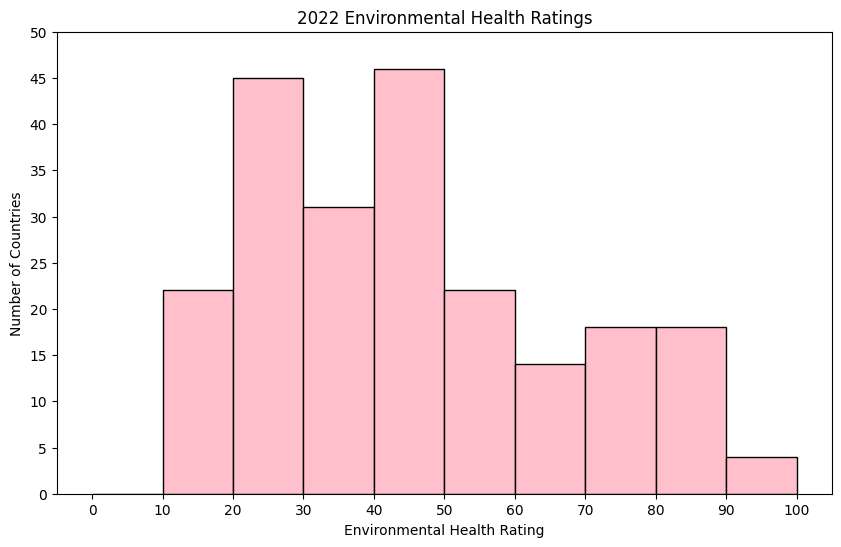

In [14]:
# Plot the rate of each country
most_recent_avgs = weighted_avgs.droplevel("iso").reorder_levels(["year", "code"]).loc[2022]

fig, ax = plt.subplots(figsize = (10, 6))

ax.hist(most_recent_avgs["weighted_avg"], bins = np.linspace(0, 100, 11), color = "pink", edgecolor = "black")
ax.set_xticks(np.linspace(0, 100, 11))
ax.set_yticks(np.linspace(0,50,11))
ax.set_title("2022 Environmental Health Ratings")
ax.set_xlabel("Environmental Health Rating")
ax.set_ylabel("Number of Countries")

From the above graph, we can determine that a large number of countries have a environmental health rating between 40 and 50, and nearly as many countries have a rating between 20 and 30. 

For the countries with a rating of 90 - 100, the graph demonstrates that there are very few, and the data just above on the best rated countries can confirm that there are exactly 4: Norway, Sweden, Finland, and Iceland. It is interesting to note that these countries are all Nordic countries located in Northern Europe. While we cannot make any definitive claims that the geographic location of these countries has any impact on their environmental health ratings, there is some potential correlation. These high ratings could be caused by renewable energy policies or a cultural emphasis on sustainability, but that is a bit beyond the scope of our analysis. 

Overall, it is clear that many countries, as of 2022, still have a lot of room for improvement in their overall environmental health, and these countries should look to the highly rated countries for insight into how they may improve their own ratings. 

### Developing a Rate of Change Quantifier: Total Difference Rate

Beyond just the weighted average, we also wanted to quantify the overall change the each country has overgone for all the years where data is available. So, we found a rate of change for the weighted averages by taking the difference of most recent year and the oldest year and then dividing by the number of years. 

In [15]:
# Find total difference for each county and divide by years to get the rate
def total_diff(country):
    country["total_diff_rate"] = ((country.iloc[-1].weighted_avg) - (country.iloc[0].weighted_avg)) / len(country)
    return country

weighted_avgs_2 = weighted_avgs.groupby('code').apply(total_diff)
weighted_avgs_total = weighted_avgs_2.droplevel(0)
weighted_avgs_total

country  weighted_avg  total_diff_rate
code iso year                                            
4    AFG 1995  Afghanistan     15.639766         0.029028
         1996  Afghanistan     15.723835         0.029028
         1997  Afghanistan     15.439104         0.029028
         1998  Afghanistan     15.224931         0.029028
         1999  Afghanistan     15.050795         0.029028
...                    ...           ...              ...
894  ZMB 2018       Zambia     21.347204         0.108386
         2019       Zambia     21.705643         0.108386
         2020       Zambia     21.711100         0.108386
         2021       Zambia     21.711100         0.108386
         2022       Zambia     21.711100         0.108386

[6160 rows x 3 columns]

### Analysis of Total Difference Rate

This information allows us to quantify overall improvement in environmental health over time. Thus, we want to compare countries based on their rate of change of environmental health scores between 1995 and 2022 and potentially make some connections to above section. 

**Which countries have the largest and smallest difference rates? Are there any countries with a negative difference rate?**

In [20]:
total_diff_only = weighted_avgs_total.droplevel("year").drop("weighted_avg", axis = 1).drop_duplicates()
total_diff_only.sort_values(by = "total_diff_rate", inplace=True)
total_diff_only.head(10), total_diff_only.tail(10)

(                  country  total_diff_rate
 code iso                                  
 426  LSO          Lesotho        -0.126526
 148  TCD             Chad        -0.098989
 732  ESH   Western Sahara        -0.097522
 716  ZWE         Zimbabwe        -0.090062
 90   SLB  Solomon Islands        -0.062984
 854  BFA     Burkina Faso        -0.051480
 586  PAK         Pakistan        -0.042334
 533  ABW            Aruba        -0.033694
 540  NCL    New Caledonia        -0.024735
 508  MOZ       Mozambique        -0.023636,
               country  total_diff_rate
 code iso                              
 462  MDV     Maldives         0.646360
 440  LTU    Lithuania         0.651181
 400  JOR       Jordan         0.665644
 196  CYP       Cyprus         0.668589
 792  TUR       Turkey         0.670747
 410  KOR  South Korea         0.724446
 702  SGP    Singapore         0.759739
 620  PRT     Portugal         0.770520
 372  IRL      Ireland         0.831099
 233  EST      Estonia         

In [21]:
num_neg = total_diff_only[total_diff_only["total_diff_rate"] < 0].count()
print(f"There are {num_neg.values[0]} countries with a negative difference rate in environmental health")

There are 23 countries with a negative difference rate in environmental health


Our first observation about the 10 lowest difference rates was that they were all negative. We had initially assumed that the lowest difference rates would be close to 0 but that they would all be positive. Not only are all the lowest rates negative, there are actually a total of 23 countries with a negative rate of change for their environmental health rating from 1995 to 2022. This was a shockingly high number and highlights the fact that many people throughout the world, especially in developing nations, face worsening environmental health conditions.

It is important to note that *Lesotho* appears in this list and was listed as one of the countries with the worst environmental health rating for 2022. We will likely analyze Lesotho closer a later on in this notebook.

Conversely, the countries with the 10 highest difference rates were all between 0.64 and 0.86, which is a surprisingly high rate of improvement. It is interesting to see *Ireland* in both this list and the highest overall ratings in 2022 list, indicating that Ireland has both high rate of improvement and a high rating. 

However, the highest improvement rate was *Estonia*, which we would not have hypothesized. We make a point of taking a closer look at this country's individual performance indicators over time later in the notebook to try to get some insight into how it achieved the highest rate of change position. 

**We also want to look at a scatterplot of weighted averages and total changes**

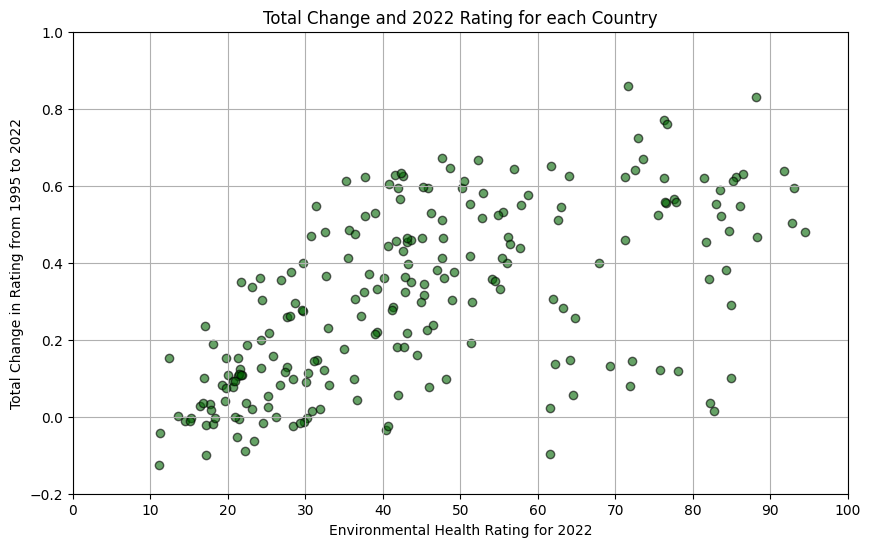

In [22]:
fig, ax = plt.subplots(figsize = (10, 6))

most_recent_avgs_total = weighted_avgs_total.xs(2022, level = 2)

ax.scatter(most_recent_avgs_total["weighted_avg"], most_recent_avgs_total["total_diff_rate"], color = "darkgreen", edgecolors="black", alpha=.60)

ax.set_xlabel("Environmental Health Rating for 2022")
ax.set_ylabel("Total Change in Rating from 1995 to 2022")
ax.set_title("Total Change and 2022 Rating for each Country")

ax.set_xticks(np.linspace(0,100,11))
ax.set_yticks(np.linspace(-0.2, 1, 7))

ax.grid(visible=True)

In [23]:
# Outlier Analysis
most_recent_avgs_total[(most_recent_avgs_total['weighted_avg'] > 60) & (most_recent_avgs_total['total_diff_rate'] < 0)]

,,country,weighted_avg,total_diff_rate
code,iso,,,
732,ESH,Western Sahara,61.542236,-0.097522


As we can see in the above graph, many countries are clustered together with low rating and low improvement, while there are no countries that have a low rating and high improvement. This intuitively makes sense, as any country that has high improvement should be moving up in rating and no longer be in the lower rating section. This also means that many countries started with low ratings and have done nothing over the last 30 years to improve that rating, suggesting that they are not focused on sustainable efforts for some reason or another. It is possible that these countries do not have the economic resources to focus on improving their environmental health, or it is possible that these countries are simply not concerned with improving their environmental health rating.

We also see that many countries are near the center of the graph, with an average Environmental Health Rating that is slowly increasing over time. The overall trend of the scatterplot showcases that there is a positive correlation between the rating in 2022 and the overall increase in rating from 1995, so as countries focus more on environmental health they are seeing positive results. As ratings in 2022 tend to get higher, we see that the overall change decreases, which means that many of the countries with the highest ratings had high ratings before 1995 and improved them over time, albeit very slowly.

One particular outlier that we wanted to do further analysis on was the only country with a rating above 40 that had a negative total change from 1995-2022. We found that that country was Western Sahara. This means that Western Sahara had a somewhat high environmental rating to start in 1995, but has not focused on improving its environmental health rating since 1995.

### Analysis of Impact of Paris Climate Agreement on Rate of Change for Environmental Health

In this section, we wanted to segment our data into before and after the Paris Climate Agreement was signed on April 22, 2016. 

The Paris Climate Agreement was an international treaty aimed at limiting the global average temperature increase to 1.5°C by reducing the participating countries' greenhouse gas emissions. It entered into force in November 2016. For more information on the Paris Climate Agreement, visit [this website](https://unfccc.int/process-and-meetings/the-paris-agreement).

Our goal is to analyze whether there is a notable difference between the environmental health rate of change before and after 2016 (when the Paris Climate Agreement went into effect). We will separately look at the countries that did and did not participate in the agreement, and see if there is a significant difference between those groups as well.

We realized that we would need to start by getting a list of which countries were actually involved in the Paris Climate Agreement, so we pulled data from a [United Nations website](https://www.un.org/sustainabledevelopment/blog/2016/04/parisagreementsingatures/)  to give us a list of those countries. We had to convert the list into a csv ourselves, but we did not alter the data in any way. You can find the csv file titled "ParisCountries.csv" in the repository.


In [26]:
paris_countries = pd.read_csv("ParisCountries.csv", usecols=["country"])
paris_countries

,country
0,Afghanistan
1,Albania
2,Algeria
3,Andorra
4,Angola
...,...
170,Uruguay
171,Vanuatu
172,Venezuela (Bolivarian Republic of)
173,Viet Nam


Here we follow the same logic and find the total change in rating difference for each country between the start of the data and 2016, and then the total change between 2016 and the end of that country's data (likely 2022). All we do is take the weighted average at the end/2016, subtract the weighted average from 2016/start, and then divide by the number of years that have passed to a slope for how much the rate has changed after/before the Paris Climate Agreement. One we have those two columns, we check to see if the rate after the PCA is greater than the rate before the PCA by calculating the difference, and adding a new column to capture that.

In [27]:
# Find difference from start-2016 and 2016-end for paris and divide by #years to get rate
def before_diff(country):
    idx = pd.IndexSlice
    years = country.index.get_level_values(-1)
    years_before = (years < 2016).sum()
    country["before_PCA_diff"] = ((country.loc[idx[:,:,2016]].weighted_avg) - (country.iloc[0].weighted_avg)) / years_before
    return country

def after_diff(country):
    idx = pd.IndexSlice
    years = country.index.get_level_values(-1)
    years_after = (years > 2016).sum()
    country["after_PCA_diff"] = ((country.iloc[-1].weighted_avg) - (country.loc[idx[:,:,2016]].weighted_avg)) / years_after
    return country


temp_diff = weighted_avgs.groupby('code').apply(before_diff).droplevel(0)
paris_diff2 = temp_diff.groupby('code').apply(after_diff)
paris_diff = paris_diff2.droplevel(0)

# Need to get the diff between before and after here
paris_diff['PCA_diff'] = paris_diff['after_PCA_diff'] - paris_diff['before_PCA_diff']

paris_diff_in = paris_diff[paris_diff["country"].isin(paris_countries.country)] #countries that signed the Paris Climate Agreement in 2016
paris_diff_out = paris_diff[~paris_diff["country"].isin(paris_countries.country)] #countries that did NOT sign the Paris Climate Agreement
# paris_diff_in, paris_diff_out

In [28]:
# Find the difference between those two rate and look for changes
paris_in_mean = paris_diff_in['PCA_diff'].mean()
paris_out_mean = paris_diff_out['PCA_diff'].mean()

print(f"Countries in the Paris Climate Agreement changed by an average of {paris_in_mean}.\nCountries outside the Paris Climate Agreement changed by an average of {paris_out_mean}.")

Countries in the Paris Climate Agreement changed by an average of -0.18875889302319052.
Countries outside the Paris Climate Agreement changed by an average of -0.07773716586274404.


From just the mean difference, we can tell that on average, countries in the Paris Climate Agreement actually had a decrease in their rate of change after entering the Paris Climate Agreement. It is worth noting that the countries that did not participate in the agreement also had an on average decrease in their rate of change, but it was less than the countries that did participate. That is to say, there was less of a decrease in the rate of change of the environmental health rating on average for countries that were not in the Paris Climate Agreement. 

These averages alone would suggest that the Paris Climate Agreement may not have been as successful as one would have assumed in its goals of limiting the impacts of climate change. However, we wanted to take a closer look at the differences to see if a graphical representation of the data supported this idea and/or if there were other observations to be made about this data.

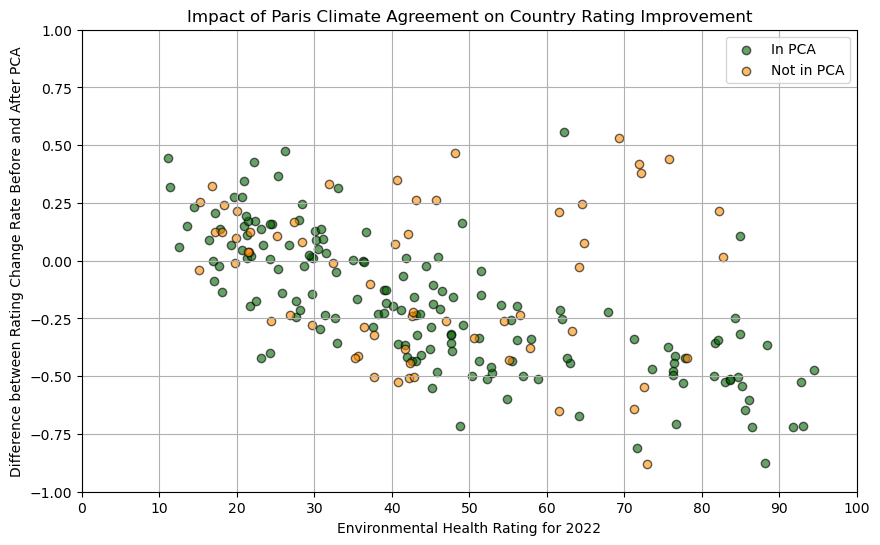

In [20]:
# Plot the diff and see if the Paris CA did anything
fig, ax = plt.subplots(figsize=(10, 6))
paris_diff_in_2022 = paris_diff_in.xs(2022, level=2)
paris_diff_out_2022 = paris_diff_out.xs(2022, level=2)
ax.scatter(paris_diff_in_2022['weighted_avg'], paris_diff_in_2022['PCA_diff'], color = "darkgreen", edgecolors="black", alpha=.60, label="In PCA")
ax.scatter(paris_diff_out_2022['weighted_avg'], paris_diff_out_2022['PCA_diff'], color = "darkorange", edgecolors="black", alpha=.60, label="Not in PCA")
ax.set_xlabel("Environmental Health Rating for 2022")
ax.set_ylabel("Difference between Rating Change Rate Before and After PCA")
ax.set_title("Impact of Paris Climate Agreement on Country Rating Improvement")

ax.set_xticks(np.linspace(0,100,11))
ax.set_yticks(np.linspace(-1, 1, 9))
ax.legend()

ax.grid(visible=True)

From the above data, we can see that countries within the Paris Climate Agreement have been improving slower after the agreement then before the agreement. We can also see that the same holds true for countries not within the Paris Climate Agreement, but they are much closer to having the same rate of improvement before and after the Paris Climate Agreement.

Based on the graph, we can infer that the closer a country comes to achieving an environmental health rating of 100, the lower their rate of growth becomes, which matches the intuition that there is less total room for improvement the closer the rating is to 100. We see a general clustering for countries with Environmental Health ratings below 30, as most have them have improved more after the Paris Climate Agreement was signed than before it was signed, no matter if they were in the Paris Climate Agreement or not; however, the highest improving countries after the Paris Climate Agreement are all within the agreement. It is also important to note that all of the highest rated countries are in the Paris Climate Agreement and all of the countries in the agreement are much more compact and follow a smooth line compared to countries not in the Paris Climate Agreement, which are much more spread out.

Interestingly enough, there is a large cluster of countries with a rating around 70-80 that have improved faster after the agreement was signed that before, but are all not in the Paris Climate Agreement. While these countries may not have signed the Paris Climate Agreement, there may have been pressure from the agreement to improve their environmental health from the existence of the agreement altogether, even if they couldn't sign it for certain geopolitical reasons. Overall, it seems that the Paris Climate Agreement is mostly targeted at countries with low Environmental Heath ratings and helping them towards a higher rating following a proven path from higher rated countries.

### Specific Country Analysis

In our analysis of the overall environmental health score and the rate of change from 1995 to 2022 of that score, we came across a few countries that seemed worth taking a closer look at. Specifically, we wanted to examine a graph of each individual performance indicator over time for these countries and see if there was anything noticeable that connects to our earlier observations about those countries.

The 3 countries we chose to look into further (and the reasons we wanted to look into them) are:
- Lesotho: had the worst environmental health score for 2022 and the worst rate of change value from 1995 to 2022
- Estonia: had the highest rate of change for environmental health, but was not listed in either the lowest or highest environmental health scores for 2022
- Ireland: had the 6th highest environmental health score for 2022, and had the 2nd highest rate of change value

**Graphics of Indicators Over Time for Countries of Interest**


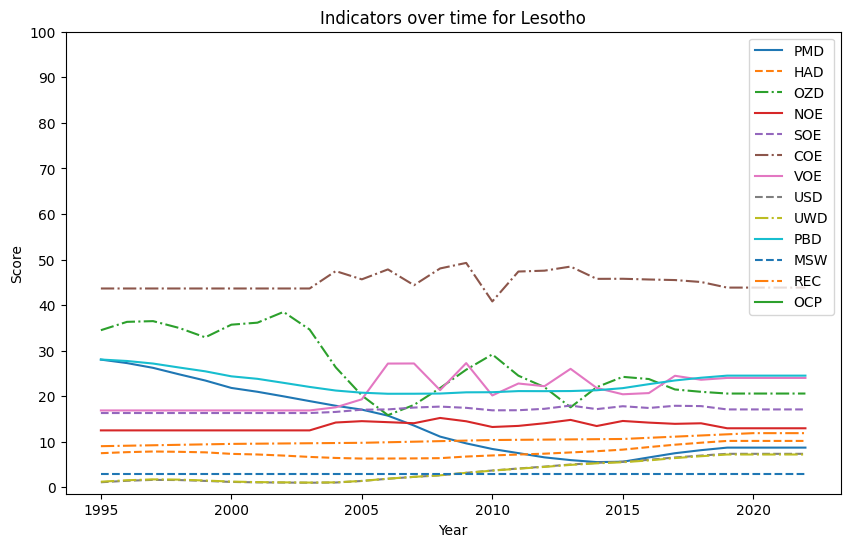

In [30]:
# get the numeric iso code for Lesotho
LES_num = iso_dict.get("Lesotho")
LES_data = all_data.loc[LES_num].value

linestyles = ['-', '--', '-.']

plt.figure(figsize=(10, 6))

i = 0
for p_i in indicators:
    plt.plot(LES_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i], linestyle = linestyles[i%3], label = p_i)
    i += 1

plt.yticks(np.linspace(0,100,11))


plt.xlabel("Year")
plt.ylabel("Score")
plt.title("Indicators over time for Lesotho") 
plt.legend()

Lesotho's graph of individual ratings showcases what we would expect for a country with a low rating and decreasing score. Most of the indicators are either flat or decreasing over the years, so it makes sense that Lesotho's total rating would follow that trend. PMD is one of the most highly rated indicators, and we can see in the above graph that it had decreased the most over time in Lesotho, so it seems that the indicator driving the decrease in Lesotho's rating the most is PMD.

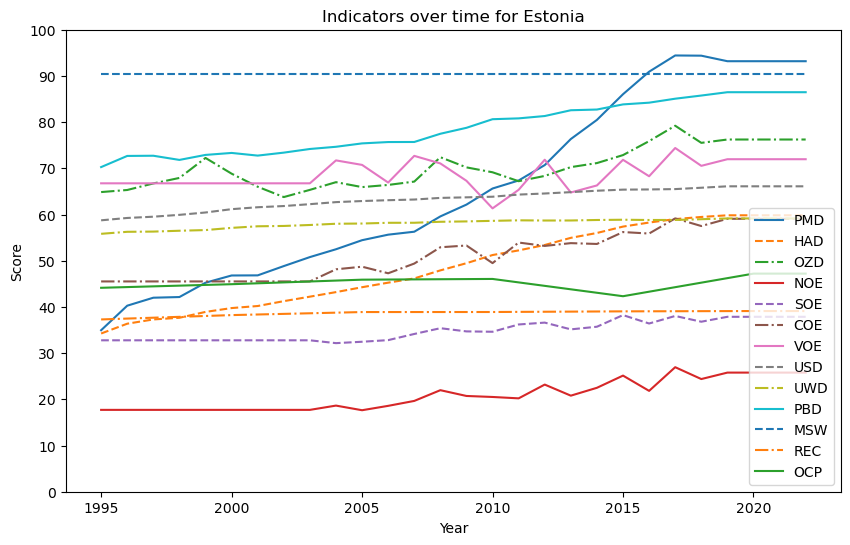

In [22]:
# get the numeric iso code for Estonia Ireland
EST_num = iso_dict.get("Estonia")
EST_data = all_data.loc[EST_num].value

linestyles = ['-', '--', '-.']

plt.figure(figsize=(10, 6))

i = 0
for p_i in indicators:
    plt.plot(EST_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i], linestyle = linestyles[i%3], label = p_i)
    i += 1


plt.yticks(np.linspace(0,100,11))


plt.xlabel("Year")
plt.ylabel("Score")
plt.title("Indicators over time for Estonia") 
plt.legend()

From Estonia's graph above, we can see that many of their individual indicator ratings are fairly low, and many of them barely increase or stay around flat over time. This might be initially surprising since many would expect that if Estonia was increasing so fast, many of the indicators should be increasing. Taking a closer look at the data, we can see that the one rating that increased drastically from 35-95 over time was PMD, which was one of the most important indicators. This likely means that Estonia as a country decided to focus on their PMD rating, since it's one of the most important aspects of Environmental Health, and it will be interesting to see if that now that their PMD rating is so high, Estonia's government will focus on another indicator.

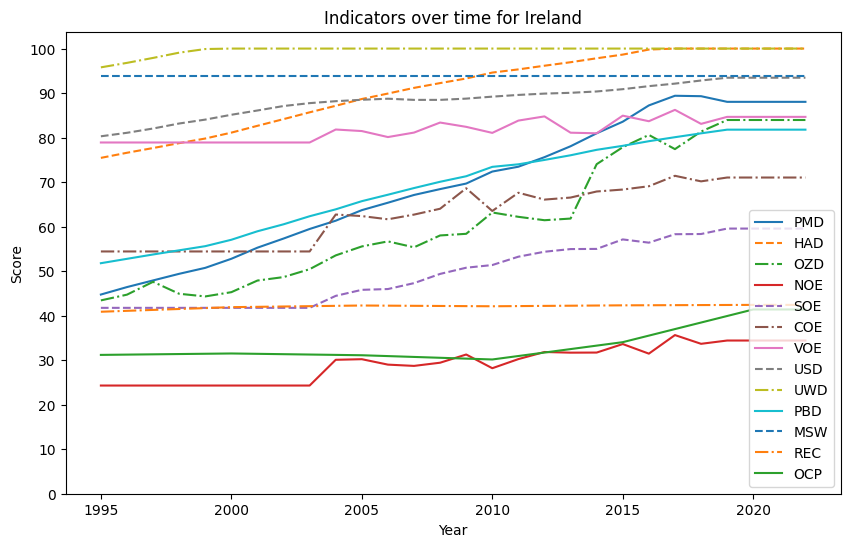

In [31]:
# get the numeric iso code for Lesotho, Estonia, Ireland
IRE_num = iso_dict.get("Ireland")
IRE_data = all_data.loc[IRE_num].value

linestyles = ['-', '--', '-.']

i = 0
plt.figure(figsize=(10, 6))
for p_i in indicators:
    plt.plot(IRE_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i], linestyle = linestyles[i%3], label = p_i)
    i += 1

plt.yticks(np.linspace(0,100,11))


plt.xlabel("Year")
plt.ylabel("Score")
plt.title("Indicators over time for Ireland") 
plt.legend()

In contrast with Estonia, we can see that many of the indicators for Ireland's environmental health are steadily increasing over time, instead of one main indicator increasing drastically over time. As Ireland's environmental health rating gets higher, we anticipate that their rate of change will become much more like the highest rated countries like Iceland and Sweden, where the rating is much lower, because there just won't be any more room to grow.

### Conclusion

### Citations

United Nations Framework Convention on Climate Change. (n.d.). The Paris Agreement. Unfccc.int. https://unfccc.int/process-and-meetings/the-paris-agreement.

United Nations. (2016, April 22). List of Parties that signed the Paris Agreement on 22 April. United Nations. https://www.un.org/sustainabledevelopment/blog/2016/04/parisagreementsingatures/ 

Yale Center For Environmental Law And Policy-YCELP-Yale University, &amp; Center For International Earth Science Information Network-CIESIN-Columbia University. (2023). <i>2022 Environmental Performance Index (EPI)</i> (Version 2022.00) [Data set]. Palisades, NY: NASA Socioeconomic Data and Applications Center (SEDAC). https://doi.org/10.7927/DWT2-9K25 Date Accessed: 2026-04-27